In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

Matplotlib is building the font cache; this may take a moment.


In [2]:
DATA_DIR = Path("../dataset")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

# Load data
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (75000, 4)
Test shape: (75000, 3)


,sample_id,catalog_content,image_link,price
0,33127,"Item Name: La Victoria Green Taco Sauce Mild, ...",https://m.media-amazon.com/images/I/51mo8htwTH...,4.89
1,198967,"Item Name: Salerno Cookies, The Original Butte...",https://m.media-amazon.com/images/I/71YtriIHAA...,13.12
2,261251,"Item Name: Bear Creek Hearty Soup Bowl, Creamy...",https://m.media-amazon.com/images/I/51+PFEe-w-...,1.97
3,55858,Item Name: Judee’s Blue Cheese Powder 11.25 oz...,https://m.media-amazon.com/images/I/41mu0HAToD...,30.34
4,292686,"Item Name: kedem Sherry Cooking Wine, 12.7 Oun...",https://m.media-amazon.com/images/I/41sA037+Qv...,66.49


In [3]:
train.info()
print("\n")
test.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        75000 non-null  int64  
 1   catalog_content  75000 non-null  object 
 2   image_link       75000 non-null  object 
 3   price            75000 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 2.3+ MB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   sample_id        75000 non-null  int64 
 1   catalog_content  75000 non-null  object
 2   image_link       75000 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


Price summary:
count    75000.000000
mean        23.647654
std         33.376932
min          0.130000
25%          6.795000
50%         14.000000
75%         28.625000
max       2796.000000
Name: price, dtype: float64


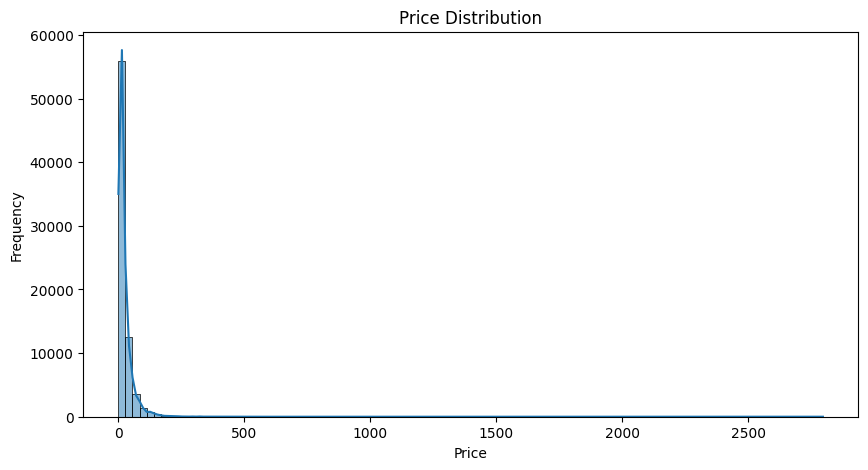

In [4]:
print("Price summary:")
print(train['price'].describe())

plt.figure(figsize=(10,5))
sns.histplot(train['price'], bins=100, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


In [5]:
print("Missing values in train:")
print(train.isnull().sum())
print("\nMissing values in test:")
print(test.isnull().sum())


Missing values in train:
sample_id          0
catalog_content    0
image_link         0
price              0
dtype: int64

Missing values in test:
sample_id          0
catalog_content    0
image_link         0
dtype: int64


In [6]:
for i in range(3):
    print(f"Sample {i+1}:")
    print(train['catalog_content'].iloc[i])
    print("="*100)


Sample 1:
Item Name: La Victoria Green Taco Sauce Mild, 12 Ounce (Pack of 6)
Value: 72.0
Unit: Fl Oz

Sample 2:
Item Name: Salerno Cookies, The Original Butter Cookies, 8 Ounce (Pack of 4)
Bullet Point 1: Original Butter Cookies: Classic butter cookies made with real butter
Bullet Point 2: Variety Pack: Includes 4 boxes with 32 cookies total
Bullet Point 3: Occasion Perfect: Delicious cookies for birthdays, weddings, anniversaries
Bullet Point 4: Shareable Treats: Fun to give and enjoy with friends and family
Bullet Point 5: Salerno Brand: Trusted brand of delicious butter cookies since 1925
Value: 32.0
Unit: Ounce

Sample 3:
Item Name: Bear Creek Hearty Soup Bowl, Creamy Chicken with Rice, 1.9 Ounce (Pack of 6)
Bullet Point 1: Loaded with hearty long grain wild rice and vegetables
Bullet Point 2: Full of hearty goodness
Bullet Point 3: Single serve bowls
Bullet Point 4: Easy to prepare mix
Bullet Point 5: 0 grams trans fat
Value: 11.4
Unit: Ounce



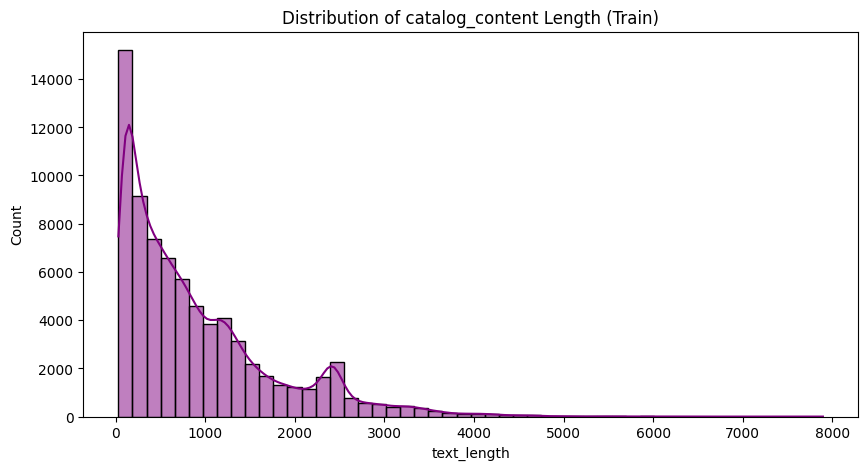

Median length: 643.0
Max length: 7894


In [7]:
train['text_length'] = train['catalog_content'].astype(str).apply(len)
test['text_length'] = test['catalog_content'].astype(str).apply(len)

plt.figure(figsize=(10,5))
sns.histplot(train['text_length'], bins=50, color='purple', kde=True)
plt.title("Distribution of catalog_content Length (Train)")
plt.show()

print("Median length:", train['text_length'].median())
print("Max length:", train['text_length'].max())


In [8]:
import re

def extract_ipq(text):
    if not isinstance(text, str):
        return np.nan
    # Extract numbers followed by units like g, kg, ml, l, pcs
    match = re.findall(r'(\d+\s?(?:g|kg|ml|l|pcs|pack|tablet|capsule|piece))', text.lower())
    return match if match else np.nan

train['ipq_raw'] = train['catalog_content'].apply(extract_ipq)
test['ipq_raw'] = test['catalog_content'].apply(extract_ipq)

print(train[['catalog_content', 'ipq_raw']].head(10))


                                     catalog_content      ipq_raw
0  Item Name: La Victoria Green Taco Sauce Mild, ...          NaN
1  Item Name: Salerno Cookies, The Original Butte...          NaN
2  Item Name: Bear Creek Hearty Soup Bowl, Creamy...        [0 g]
3  Item Name: Judee’s Blue Cheese Powder 11.25 oz...          NaN
4  Item Name: kedem Sherry Cooking Wine, 12.7 Oun...          NaN
5  Item Name: Member's Mark Member's Mark, Basil,...          NaN
6  Item Name: Goya Foods Sazonador Total Seasonin...          NaN
7  Item Name: VineCo Original Series Chilean Sauv...  [8 l, 23 l]
8  Item Name: NATURES PATH CEREAL FLK MULTIGRAIN ...          NaN
9  Item Name: Mrs. Miller's Seedless Black Raspbe...          NaN


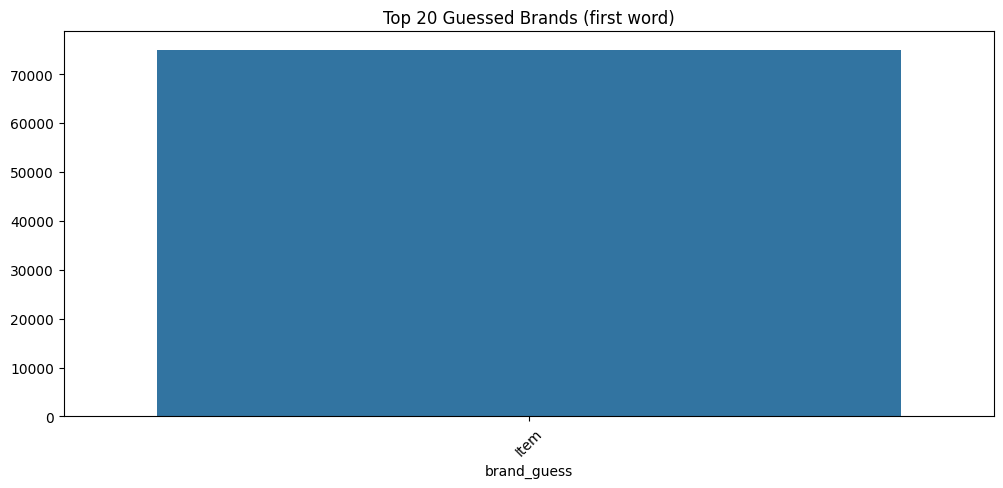

In [9]:
# crude brand extraction = first word(s) of catalog_content
train['brand_guess'] = train['catalog_content'].astype(str).str.split().str[0]
brand_counts = train['brand_guess'].value_counts().head(20)

plt.figure(figsize=(12,5))
sns.barplot(x=brand_counts.index, y=brand_counts.values)
plt.xticks(rotation=45)
plt.title("Top 20 Guessed Brands (first word)")
plt.show()


In [10]:
print("Train columns:", train.columns.tolist())
print("Test columns:", test.columns.tolist())


Train columns: ['sample_id', 'catalog_content', 'image_link', 'price', 'text_length', 'ipq_raw', 'brand_guess']
Test columns: ['sample_id', 'catalog_content', 'image_link', 'text_length', 'ipq_raw']
